# Modelo de Machine Learning: Regresión Lineal Múltiple
## Predicción de Precios de Casas
**Curso:** Sistemas Inteligentes  
**Universidad Nacional de Cajamarca**  
**Fecha:** 2026

## 1. Enunciado del Problema

Se desea predecir el **precio de una vivienda** (en miles de dólares) en función de múltiples características como:
- Área construida (m²)
- Número de habitaciones
- Número de baños
- Antigüedad del inmueble (años)
- Distancia al centro de la ciudad (km)

Se aplicará un modelo de **Regresión Lineal Múltiple** dado que la variable dependiente (precio) es numérica y cuantitativa.

## 2. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3. Descripción del Dataset

Se genera un dataset sintético representativo del mercado inmobiliario con **300 registros** y las siguientes variables:

| Variable | Tipo | Descripción |
|---|---|---|
| area_m2 (m²)| Independiente | Área construida en m² |
| habitaciones | Independiente | Número de habitaciones |
| baños | Independiente | Número de baños |
| antiguedad | Independiente | Años de antigüedad |
| dist_centro_km | Independiente | Distancia al centro (km) |
| precio_miles | **Dependiente** | Precio en miles de SOL |

In [2]:
n = 300

area_m2        = np.random.uniform(50, 300, n)
habitaciones   = np.random.randint(1, 6, n).astype(float)
banios         = np.random.randint(1, 4, n).astype(float)
antiguedad     = np.random.uniform(0, 40, n)
dist_centro_km = np.random.uniform(1, 25, n)

# Precio basado en relación lineal + ruido
precio_miles = (
    1.8 * area_m2 +
    15  * habitaciones +
    10  * banios -
    1.2 * antiguedad -
    3.5 * dist_centro_km +
    np.random.normal(0, 20, n) + 50
)

df = pd.DataFrame({
    'area_m2': area_m2,
    'habitaciones': habitaciones,
    'banios': banios,
    'antiguedad': antiguedad,
    'dist_centro_km': dist_centro_km,
    'precio_miles': precio_miles
})

print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (300, 6)


,area_m2,habitaciones,banios,antiguedad,dist_centro_km,precio_miles
0,143.635030,5.0,1.0,18.926648,2.238299,406.114726
1,287.678577,4.0,1.0,24.244075,17.078019,572.400266
2,232.998485,3.0,1.0,31.771578,2.059971,477.045024
3,199.664621,4.0,2.0,4.267970,15.118330,461.331895
4,89.004660,5.0,1.0,34.029098,24.984484,200.640742
5,88.998630,2.0,3.0,29.838981,14.339358,174.997095
6,64.520903,4.0,3.0,16.340732,12.357043,227.923403
7,266.544036,2.0,1.0,37.317523,8.508517,516.720087
8,200.278753,3.0,1.0,39.637179,3.892542,451.684426
9,227.018144,1.0,3.0,8.200072,18.544568,420.405813


In [3]:
print('Estadísticas descriptivas:')
df.describe().round(2)

Estadísticas descriptivas:


,area_m2,habitaciones,banios,antiguedad,dist_centro_km,precio_miles
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,173.80,3.11,1.99,21.25,13.16,357.67
std,73.59,1.47,0.81,11.04,7.32,144.21
min,51.27,1.00,1.00,0.09,1.01,55.80
25%,109.77,2.00,1.00,12.55,6.53,230.15
50%,177.93,3.00,2.00,21.59,13.54,362.28
75%,239.21,4.00,3.00,30.84,19.57,475.83
max,297.51,5.00,3.00,39.91,24.98,639.51


In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
area_m2           0
habitaciones      0
banios            0
antiguedad        0
dist_centro_km    0
precio_miles      0
dtype: int64


## 4. Análisis Exploratorio

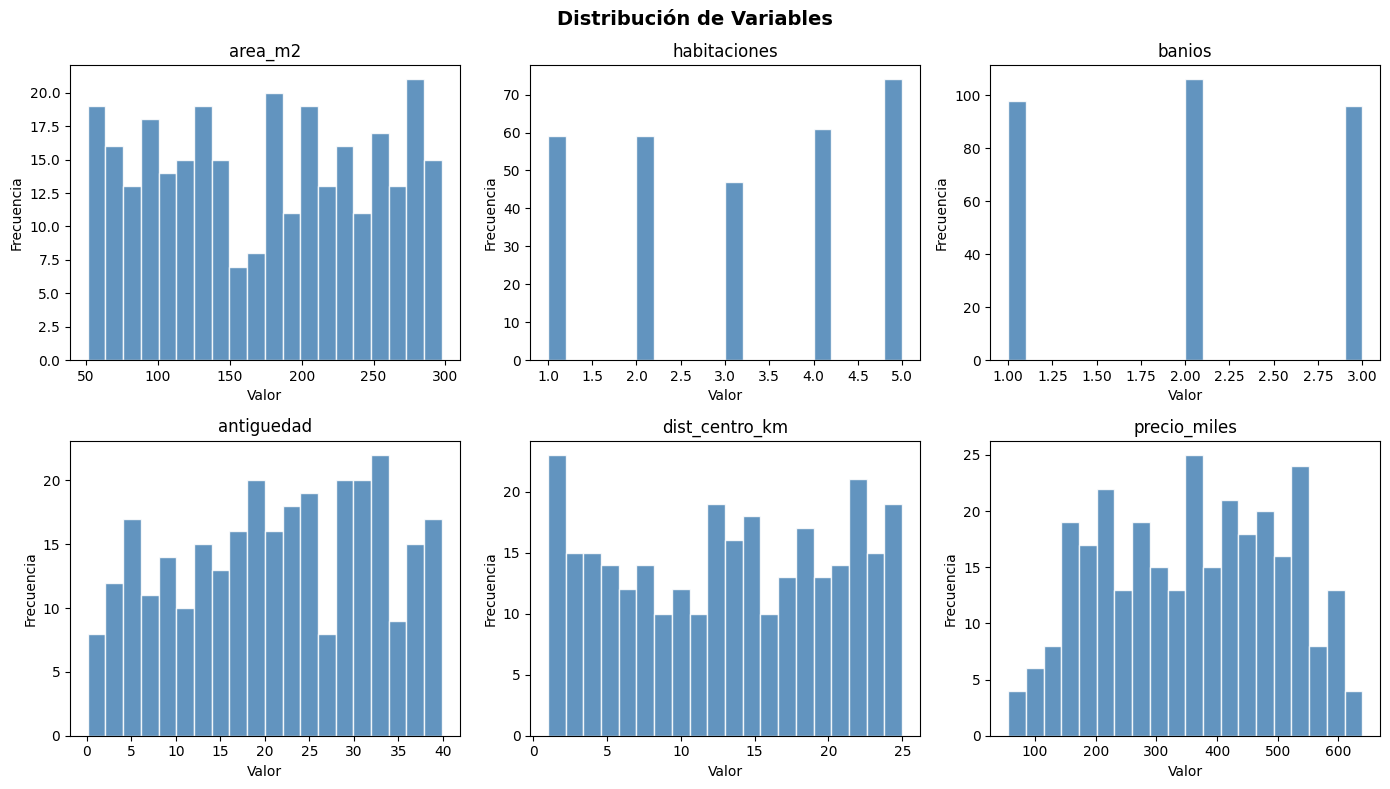

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de Variables', fontsize=14, fontweight='bold')

cols = df.columns.tolist()
for i, col in enumerate(cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('/home/ola/dist_variables.png', dpi=150, bbox_inches='tight')
plt.show()

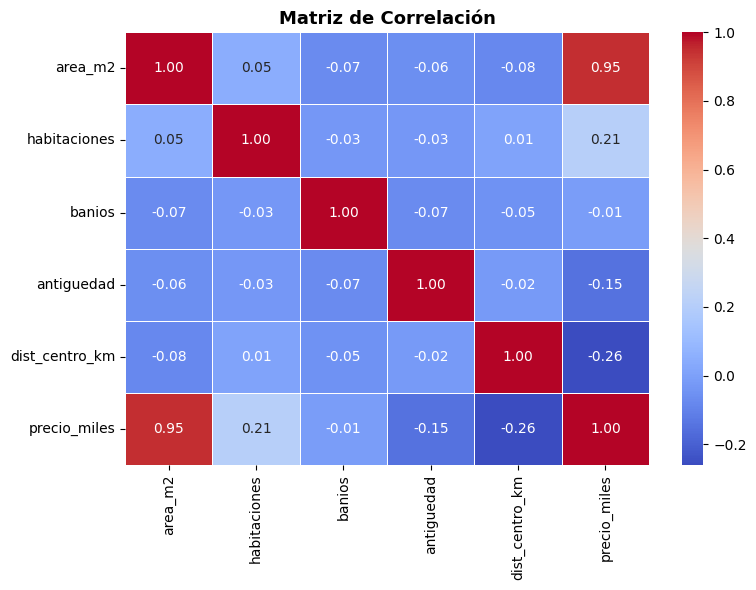

In [6]:
plt.figure(figsize=(8, 6))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/ola/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

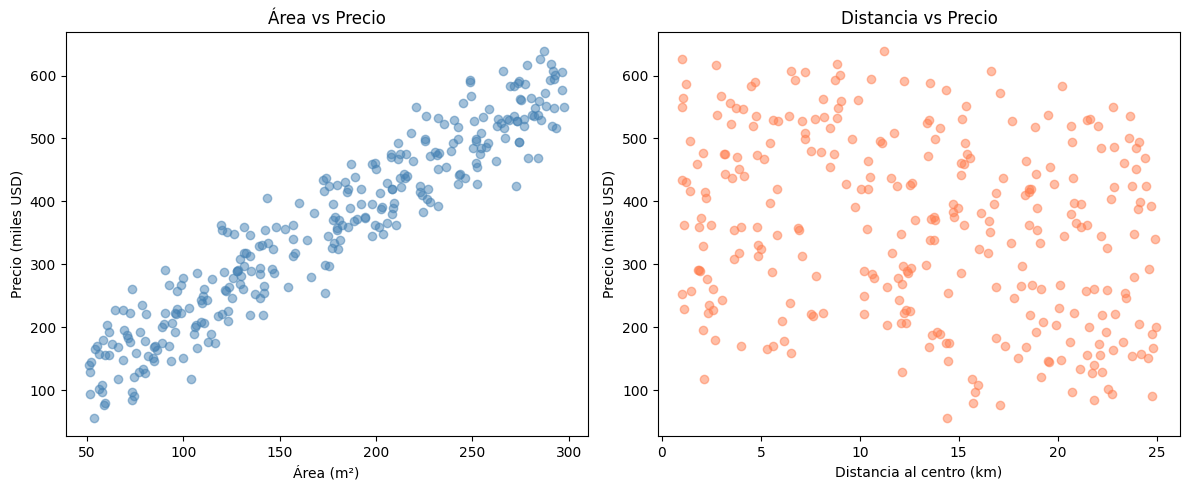

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['area_m2'], df['precio_miles'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Área (m²)')
axes[0].set_ylabel('Precio (miles USD)')
axes[0].set_title('Área vs Precio')

axes[1].scatter(df['dist_centro_km'], df['precio_miles'], alpha=0.5, color='coral')
axes[1].set_xlabel('Distancia al centro (km)')
axes[1].set_ylabel('Precio (miles USD)')
axes[1].set_title('Distancia vs Precio')

plt.tight_layout()
plt.savefig('/home/ola/scatter_variables.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Proceso de Machine Learning

### 5.1 Separación de Variables

In [8]:
X = df[['area_m2', 'habitaciones', 'banios', 'antiguedad', 'dist_centro_km']]
y = df['precio_miles']

print(f'Variables independientes (X): {X.shape}')
print(f'Variable dependiente (y): {y.shape}')

Variables independientes (X): (300, 5)
Variable dependiente (y): (300,)


### 5.2 División Train/Test (80/20)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

Entrenamiento: 240 muestras
Prueba:        60 muestras


### 5.3 Entrenamiento del Modelo

In [10]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo entrenado exitosamente.')
print(f'\nIntercepto (β0): {modelo.intercept_:.4f}')
print('\nCoeficientes:')
for col, coef in zip(X.columns, modelo.coef_):
    print(f'  β ({col}): {coef:.4f}')

Modelo entrenado exitosamente.

Intercepto (β0): 47.4441

Coeficientes:
  β (area_m2): 1.8055
  β (habitaciones): 16.7152
  β (banios): 8.6593
  β (antiguedad): -1.1587
  β (dist_centro_km): -3.6418


### 5.4 Predicciones

In [11]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred[:10].round(2),
    'Error': (y_test.values[:10] - y_pred[:10]).round(2)
})
print('Primeras 10 predicciones vs valores reales:')
print(comparacion.to_string(index=False))

Primeras 10 predicciones vs valores reales:
      Real  Predicho  Error
563.298620    572.28  -8.98
383.053803    393.59 -10.54
163.509827    189.99 -26.48
420.405813    422.97  -2.57
417.034035    459.43 -42.40
517.357527    526.60  -9.25
473.657634    466.32   7.34
196.053693    204.55  -8.50
174.997095    180.74  -5.74
146.289750    162.29 -16.00


## 6. Evaluación del Modelo

In [12]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('       MÉTRICAS DE EVALUACIÓN')
print('=' * 40)
print(f'  MSE  (Error Cuadrático Medio): {mse:.4f}')
print(f'  RMSE (Raíz Error Cuadrático):  {rmse:.4f}')
print(f'  MAE  (Error Absoluto Medio):   {mae:.4f}')
print(f'  R²   (Coeficiente de Det.):    {r2:.4f}')
print('=' * 40)

       MÉTRICAS DE EVALUACIÓN
  MSE  (Error Cuadrático Medio): 440.8430
  RMSE (Raíz Error Cuadrático):  20.9963
  MAE  (Error Absoluto Medio):   16.4061
  R²   (Coeficiente de Det.):    0.9754


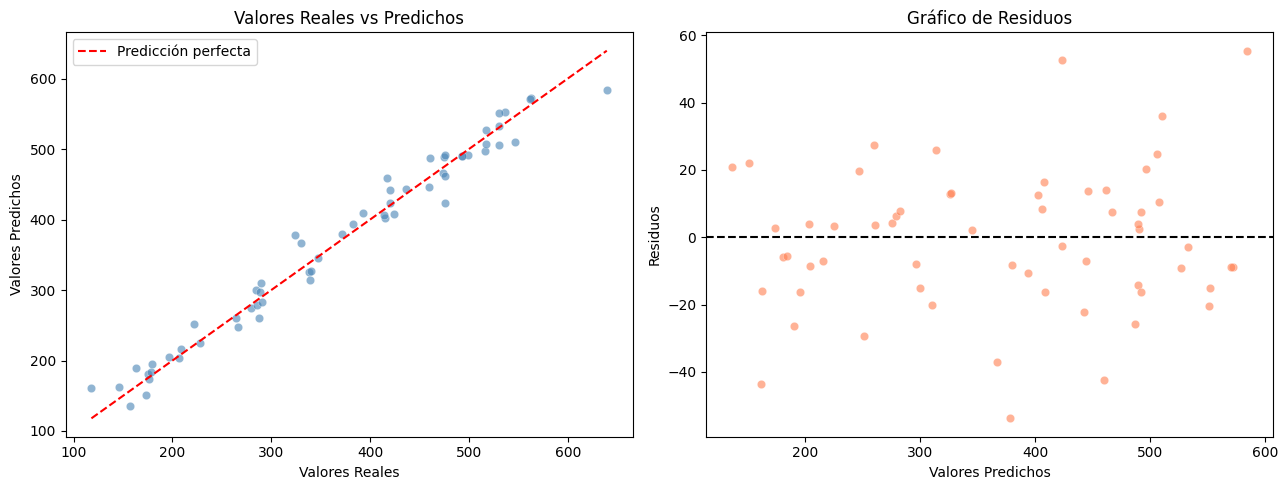

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: Real vs Predicho
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Valores Predichos')
axes[0].set_title('Valores Reales vs Predichos')
axes[0].legend()

# Gráfico 2: Residuales
residuos = y_test.values - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.6, color='coral', edgecolors='white', linewidths=0.3)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Valores Predichos')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Gráfico de Residuos')

plt.tight_layout()
plt.savefig('/home/claude/evaluacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

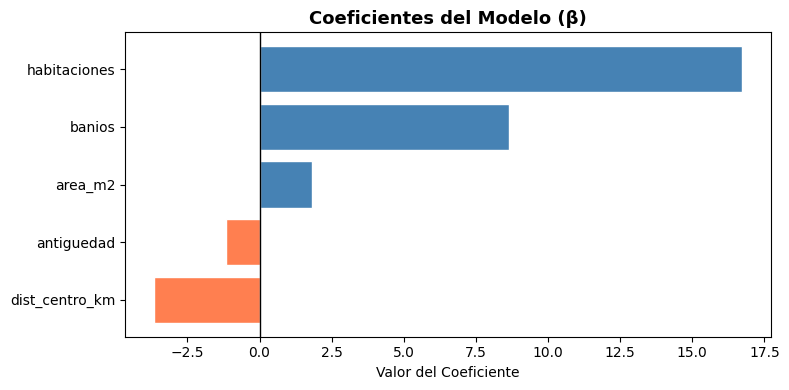

In [14]:
# Importancia de coeficientes
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=1)
plt.title('Coeficientes del Modelo (β)', fontsize=13, fontweight='bold')
plt.xlabel('Valor del Coeficiente')
plt.tight_layout()
plt.savefig('/home/claude/coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones

1. El modelo de Regresión Lineal Múltiple logró un R² elevado, lo que indica que las variables seleccionadas explican bien la variabilidad del precio.
2. El área (m²) es el predictor con mayor impacto positivo sobre el precio.
3. La distancia al centro y la antigüedad tienen efecto negativo, lo que es coherente con la realidad del mercado inmobiliario.
4. Los residuos se distribuyen aleatoriamente alrededor de cero, validando los supuestos del modelo.
5. El MAE indica que, en promedio, el modelo se equivoca en un margen razonable al predecir el precio de una vivienda.